In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo

In [2]:
from matplotlib import font_manager as fm

font_dirs = '/global/u2/s/shamikg/.local/share/fonts/'
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    fm.fontManager.addfont(font_file)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"]  = "Myriad Pro"

In [8]:

box_length_in_m = 10000.0
site_altitude = 5110.0  # Atacama altitude in meters
UTC_hour = 15

# Generate some random data for the cube
data = np.load('/pscratch/sd/s/shamikg/atmo3/examples/atmo_fields_UTC15.npz')['water_vapor_density']

Text(0, 0.5, 'z (m)')

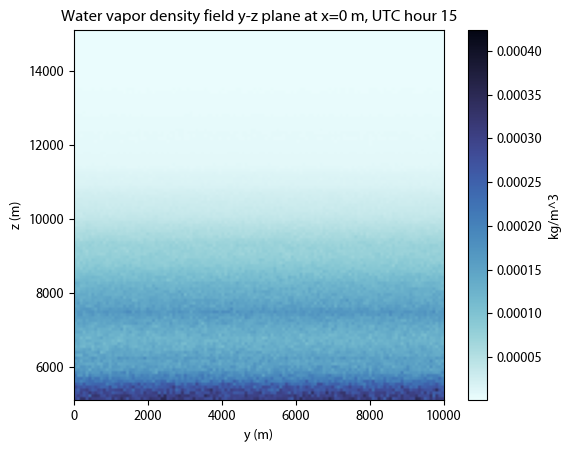

In [9]:
sub_sample = 8 

# Get the subsampled data
subsampled_data = data[::sub_sample,::sub_sample,::sub_sample]

plt.imshow(
    subsampled_data[0].T,
    extent=(0, box_length_in_m, site_altitude, site_altitude + box_length_in_m),cmap=cmo.cm.ice_r, origin='lower', vmin=data.min(), vmax=data.max()
)
plt.colorbar(label='kg/m^3')
plt.title(f"Water vapor density field y-z plane at x=0 m, UTC hour {UTC_hour}")
plt.xlabel('y (m)')
plt.ylabel('z (m)')

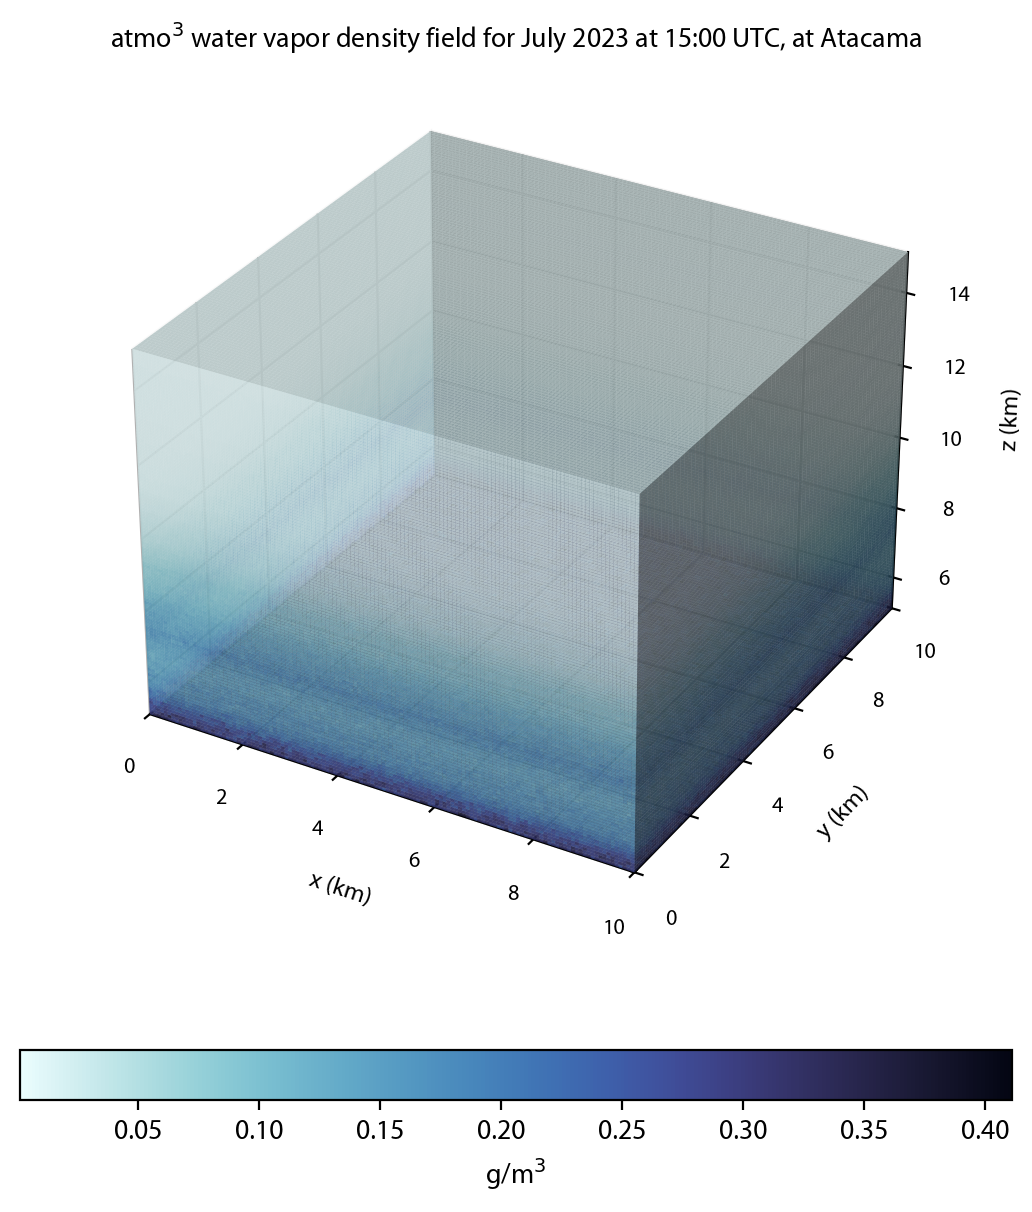

In [18]:

# Create a 3D figure
import matplotlib

fig = plt.figure(figsize=(16, 8), dpi=200)
fig.tight_layout(pad=3)
ax = fig.add_subplot(111, projection='3d')

# Create coordinate grids with proper scaling
x = np.linspace(0,   10,   subsampled_data.shape[0]+1)
y = np.linspace(0,   10,   subsampled_data.shape[1]+1)
z = np.linspace(5.1, 15.1, subsampled_data.shape[2]+1)
x, y, z = np.meshgrid(x, y, z, indexing='ij')

# Plot the cube with transparency
# r_cube = np.random.rand(*subsampled_data.shape)
colors = cmo.cm.ice_r(subsampled_data / subsampled_data.max())
norm   = matplotlib.colors.Normalize(vmin=subsampled_data.min()*1000, vmax=subsampled_data.max()*1000)
ax.voxels(x, y, z, subsampled_data > -1., edgecolor=None, facecolors=colors, alpha=0.75)

# Set axis limits
ax.set_xlim(0, x.max())
ax.set_ylim(0, y.max())
ax.set_zlim(z.min(), z.max())

ax.xaxis.set_tick_params(labelsize=8)
ax.yaxis.set_tick_params(labelsize=8)
ax.zaxis.set_tick_params(labelsize=8)

ax.set_xlabel('x (km)', fontdict={'fontsize': 9})
ax.set_ylabel('y (km)', fontdict={'fontsize': 9})
ax.set_zlabel('z (km)', fontdict={'fontsize': 9})
plt.title(r"atmo${}^3$ water vapor density field for July 2023 at 15:00 UTC, at Atacama", fontdict={'fontsize': 10})
# Show the plot

fig.colorbar(plt.cm.ScalarMappable(cmap=cmo.cm.ice_r, norm=norm), ax=ax, label=r'g/m${}^3$', shrink=0.4, aspect=20, pad=0.1, orientation='horizontal', fraction=0.2)
plt.show()

Text(0.5, 1.0, 'atmo${}^3$ water vapor density profile at Atacama\nfor July 2023 at 15:00 UTC')

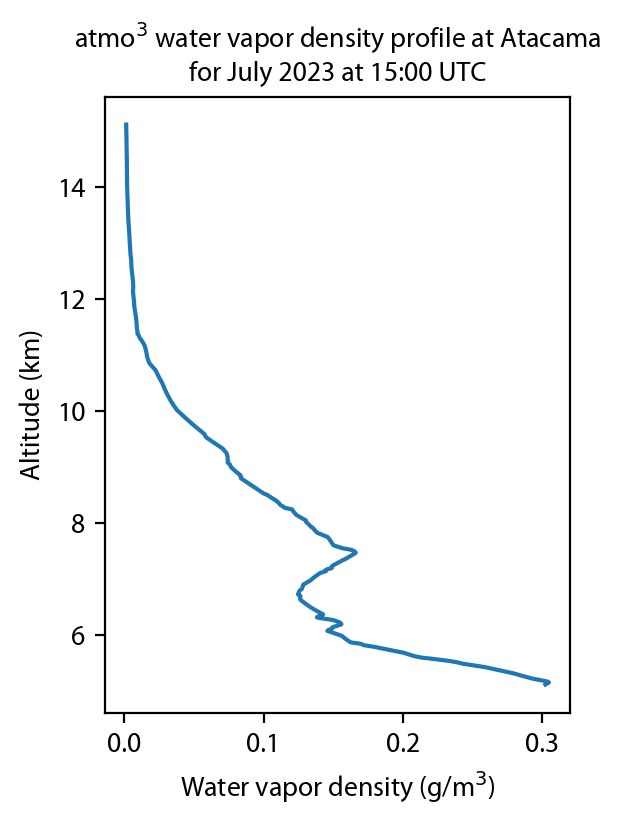

In [24]:
altitude = np.linspace(site_altitude, site_altitude + box_length_in_m, data.shape[2])
water_vapor_density_profile = np.mean(np.mean(data, axis=0), axis=0)

plt.figure(figsize=(3, 4), dpi=200)
plt.plot(water_vapor_density_profile*1000, altitude/1000, '-', linewidth=1.5)
plt.xlabel(r'Water vapor density (g/m${}^3$)', fontdict={'fontsize': 10})
plt.ylabel('Altitude (km)', fontdict={'fontsize': 10})
plt.title(r"atmo${}^3$ water vapor density profile at Atacama" "\n" r"for July 2023 at 15:00 UTC", fontdict={'fontsize': 10})

100%|██████████| 128/128 [00:00<00:00, 1290.29it/s]


-0.09680868042841903 0.1086608742312053


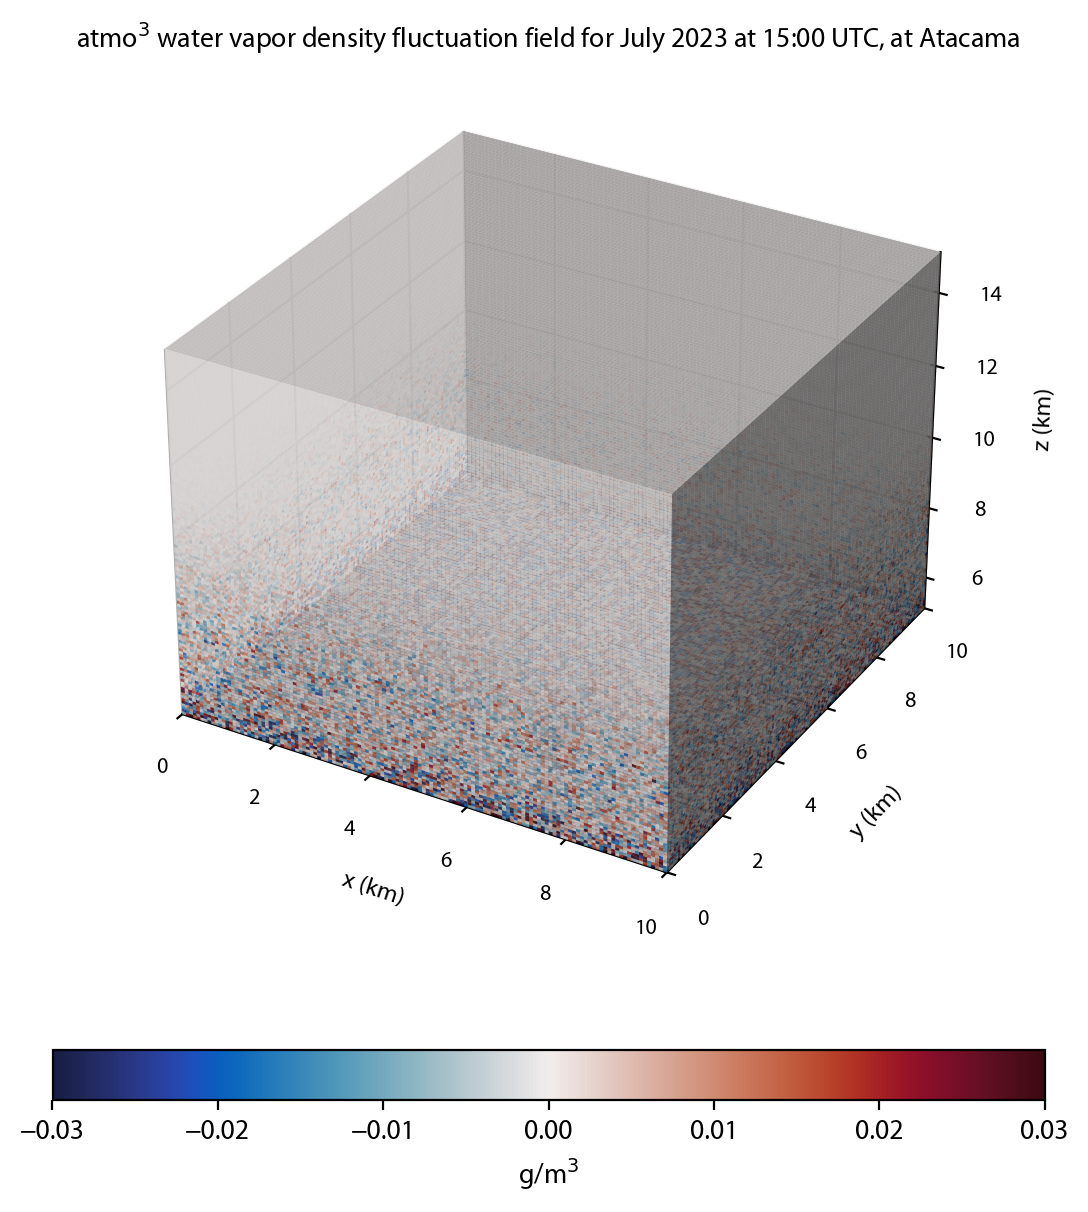

In [10]:

# Create a 3D figure
import matplotlib
from tqdm import tqdm

fig = plt.figure(figsize=(16, 8), dpi=200)
fig.tight_layout(pad=3)
ax = fig.add_subplot(111, projection='3d')

# Create coordinate grids with proper scaling
x = np.linspace(0,   10,   subsampled_data.shape[0]+1)
y = np.linspace(0,   10,   subsampled_data.shape[1]+1)
z = np.linspace(5.1, 15.1, subsampled_data.shape[2]+1)
x, y, z = np.meshgrid(x, y, z, indexing='ij')

subsampled_data *= 1e3  # convert to g/m^3

# Remove the mean profile
water_vapor_density_profile = np.mean(np.mean(subsampled_data, axis=0), axis=0)
# print(water_vapor_density_profile.shape)
for i in tqdm(range(subsampled_data.shape[2])):
    subsampled_data[:, :, i] = subsampled_data[:, :, i] - water_vapor_density_profile[i]

print( subsampled_data.min(), subsampled_data.max() )
sat_min = -0.03
sat_max =  0.03

subsampled_data = np.clip(subsampled_data, sat_min, sat_max)
transformed_data = subsampled_data - subsampled_data.min()
transformed_data = transformed_data / transformed_data.max()
# print(transformed_data.min(), transformed_data.max())
# Plot the cube with transparency
# r_cube = np.random.rand(*subsampled_data.shape)
colors = cmo.cm.balance(transformed_data)
norm   = matplotlib.colors.Normalize(vmin=sat_min, vmax=sat_max)
ax.voxels(x, y, z, subsampled_data != np.nan, edgecolor=None, facecolors=colors, alpha=0.75)

# Set axis limits
ax.set_xlim(0, x.max())
ax.set_ylim(0, y.max())
ax.set_zlim(z.min(), z.max())

ax.xaxis.set_tick_params(labelsize=8)
ax.yaxis.set_tick_params(labelsize=8)
ax.zaxis.set_tick_params(labelsize=8)

ax.set_xlabel('x (km)', fontdict={'fontsize': 9})
ax.set_ylabel('y (km)', fontdict={'fontsize': 9})
ax.set_zlabel('z (km)', fontdict={'fontsize': 9})
plt.title(r"atmo${}^3$ water vapor density fluctuation field for July 2023 at 15:00 UTC, at Atacama", fontdict={'fontsize': 10})
# Show the plot

fig.colorbar(plt.cm.ScalarMappable(cmap=cmo.cm.balance, norm=norm), ax=ax, label=r'g/m${}^3$', shrink=0.4, aspect=20, pad=0.1, orientation='horizontal', fraction=0.2)
plt.show()